In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LinearRegression


In [2]:
import sklearn
sklearn.__version__

'1.6.1'

In [3]:
df=pd.DataFrame({
    'study_time':[1,3,4,5,6,7,8,9],
    'Marks':[20,35,40,51,64,78,85,98]
})
df


,study_time,Marks
0,1,20
1,3,35
2,4,40
3,5,51
4,6,64
5,7,78
6,8,85
7,9,98


In [4]:
df.corr()

,study_time,Marks
study_time,1.000000,0.991657
Marks,0.991657,1.000000


Text(0.5, 1.0, 'Study Time vs Marks')

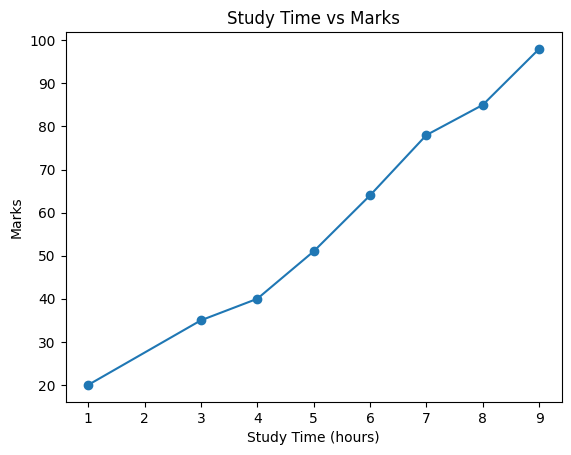

In [5]:
plt.plot(df['study_time'], df['Marks'], marker='o')

plt.xlabel('Study Time (hours)')
plt.ylabel('Marks')
plt.title('Study Time vs Marks')

In [6]:
df.size

16

In [7]:
df.columns

Index(['study_time', 'Marks'], dtype='object')

In [8]:
df.describe()

,study_time,Marks
count,8.00000,8.00000
mean,5.37500,58.87500
std,2.66927,27.00496
min,1.00000,20.00000
25%,3.75000,38.75000
50%,5.50000,57.50000
75%,7.25000,79.75000
max,9.00000,98.00000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   study_time  8 non-null      int64
 1   Marks       8 non-null      int64
dtypes: int64(2)
memory usage: 260.0 bytes


In [10]:
model=LinearRegression()

In [11]:
model

LinearRegression()

In [12]:
X=df[['study_time']]
y=df[['Marks']]

In [13]:
type(X)

pandas.core.frame.DataFrame

In [14]:
model.fit(X,y)       # training part
# It try to learn and understanding pattern and behaviour of data
# X: dtype: Pandas Dataframe: Series not allowed: 2d shape

LinearRegression()

In [15]:
#fit represents : model created successfully and ready to check

In [16]:
# Equation of line
# y=m*x+c
# m: slope
# c: intercept
# model.fit() : It will give best line

In [17]:
c= model.intercept_              #finding the value of c:bias
m = model.coef_[0]                #finding coefficint of x (m)

print(c,m)

[4.94987469] [10.03258145]


In [18]:
type(m)

numpy.ndarray

In [19]:
# marks=m * study-time + c

study_time=float(input("Enter your study hours to predict Marks: "))
marks=m * study_time + c
if 0<=marks<=100:
    print('Your predicted marks', round(marks[0],2))
elif marks<0:
    print('Invalid input')
else:
    marks=100
    print('Your predicted marks', marks)



Enter your study hours to predict Marks: 8.5
Your predicted marks 90.23


In [20]:
y_pred = model.predict(X)
print(y_pred)

[[14.98245614]
 [35.04761905]
 [45.0802005 ]
 [55.11278195]
 [65.14536341]
 [75.17794486]
 [85.21052632]
 [95.24310777]]


Text(0.5, 1.0, 'Study Time vs Marks')

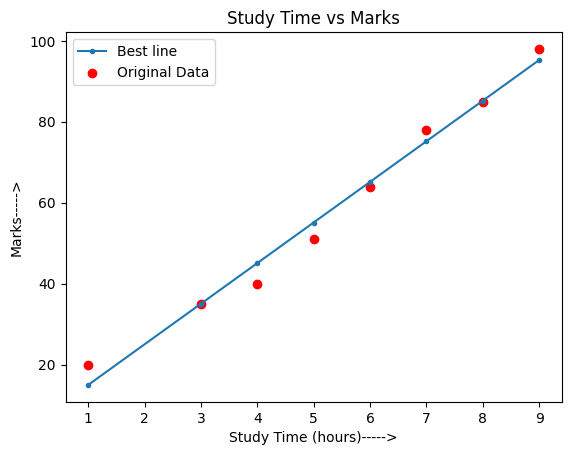

In [21]:
#checks the correctness of the model

plt.plot(df['study_time'],y_pred, marker='.',label='Best line')
plt.scatter(X,y,color='r',label='Original Data')

plt.xlabel('Study Time (hours)----->')
plt.ylabel('Marks----->')
plt.legend()
plt.title('Study Time vs Marks')

In [22]:
 MAE=(y - y_pred).abs().mean()
 print("Mean squared Error: ",round(MAE,2))

Mean squared Error:  Marks    2.65
dtype: float64


In [23]:
 MSE=((y - y_pred)**2).mean()
 print("Mean squared Error: ",round(MSE,2))

Mean squared Error:  Marks    10.6
dtype: float64


In [24]:
import math
RMSE = math.sqrt(MSE)
print("Root Mean squared Error: ",round(RMSE,2))

Root Mean squared Error:  3.26


/tmp/ipykernel_28414/4029808864.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  RMSE = math.sqrt(MSE)


In [25]:
# model score
score = model.score(X,y)*100
print("Model has Achieved: ",round(score,2),"%")


Model has Achieved:  98.34 %
